<h1>Task 1<h1> 

### Problem Definition ###

- Problem statement: This project predicts the probability of daily wildfire risk in forested regions of Azerbaijan using weather and soil data, going beyond standard weather forecasts by estimating risk rather than reporting conditions.


- Why it matters: This prediction can help emergency response teams detect high-risk days earlier and assist agricultural planners in managing land use and irrigation, especially in regions like Zaqatala and Lankaran.


- Prediction target: 
    - **Primary**: Daily wildfire risk probability (binary classification: 1 = high risk, 0 = low risk)
    - **Secondary**: Daily soil temperature/moisture (Regression) and Summer "Heat Wave" probability (Statistical).


- Cities:
    - Zaqatala: 41.6336, 46.6433  
    - Lankaran: 38.7529, 48.8515  
    - Guba: 41.3597, 48.5134  
    - + 12 additional cities across Azerbaijan  


- Weather/Soil variables: 
    - temperature_2m_max  
    - temperature_2m_min  
    - precipitation_sum  
    - wind_speed_10m_max  
    - vapour_pressure_deficit  
    - soil_temperature_0_to_7cm  
    - soil_moisture_7_to_28cm

- Other Datas:
    - NASA Satellite images to check actual cloud locations as well as fire occurances, and to detect fuel materials for fire occuring
    - Map of Azerbaijan Forestry(border lines)

<h1>Task 2<h1>

In [ ]:
import openmeteo_requests
import requests_cache
import pandas as pd
import seaborn as sns
from retry_requests import retry
import time 
import numpy as np
import requests
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import geopandas as gpd
import folium
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, r2_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [15]:
# Baku Coordinates
LAT, LON = 40.4093, 49.8671

# --- 1. Fetch 2 Years Historical Data ---
hist_url = "https://archive-api.open-meteo.com/v1/archive"
hist_params = {
    "latitude": LAT, "longitude": LON,
    "start_date": "2023-01-01", "end_date": "2024-12-31",
    "daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum", "wind_speed_10m_max"],
    "timezone": "auto"
}
hist_response = requests.get(hist_url, params=hist_params).json()
df_hist = pd.DataFrame(hist_response['daily'])
df_hist['time'] = pd.to_datetime(df_hist['time'])

# --- 2. Fetch 7-Day Forecast Data ---
fore_url = "https://api.open-meteo.com/v1/forecast"
fore_params = {
    "latitude": LAT, "longitude": LON,
    "daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum", "wind_speed_10m_max"],
    "timezone": "auto"
}
fore_response = requests.get(fore_url, params=fore_params).json()
df_fore = pd.DataFrame(fore_response['daily'])
df_fore['time'] = pd.to_datetime(df_fore['time'])

# --- 3. Inspection Reports ---
def report_data(df, title):
    print(f"\n{'='*10} {title} {'='*10}")
    print(f"Shape: {df.shape}")
    print(f"Date Range: {df['time'].min().date()} to {df['time'].max().date()}")
    print(f"Data Types:\n{df.dtypes}")
    print(f"Missing Values:\n{df.isnull().sum()}")

report_data(df_hist, "Historical Data (Baku)")
report_data(df_fore, "Forecast Data (Baku)")


========== Historical Data (Baku) ==========
Shape: (731, 5)
Date Range: 2023-01-01 to 2024-12-31
Data Types:
time                  datetime64[us]
temperature_2m_max           float64
temperature_2m_min           float64
precipitation_sum            float64
wind_speed_10m_max           float64
dtype: object
Missing Values:
time                  0
temperature_2m_max    0
temperature_2m_min    0
precipitation_sum     0
wind_speed_10m_max    0
dtype: int64

========== Forecast Data (Baku) ==========
Shape: (7, 5)
Date Range: 2026-04-20 to 2026-04-26
Data Types:
time                  datetime64[us]
temperature_2m_max           float64
temperature_2m_min           float64
precipitation_sum            float64
wind_speed_10m_max           float64
dtype: object
Missing Values:
time                  0
temperature_2m_max    0
temperature_2m_min    0
precipitation_sum     0
wind_speed_10m_max    0
dtype: int64


In [16]:
 # 1. Setup the API client 
 
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)
url = "https://archive-api.open-meteo.com/v1/archive"



In [17]:
 # 2. Define your locations (Major districts for country-wide coverage)

azerbaijan_cities = {
    "Baku": {"lat": 40.4093, "lon": 49.8671},
    "Ganja": {"lat": 40.6828, "lon": 46.3606},
    "Lankaran": {"lat": 38.7529, "lon": 48.8515},
    "Guba": {"lat": 41.3597, "lon": 48.5134},
    "Zaqatala": {"lat": 41.6336, "lon": 46.6433},
    "Nakhchivan": {"lat": 39.2089, "lon": 45.4122},
    "Sheki": {"lat": 41.1919, "lon": 47.1706},
    "Shirvan": {"lat": 39.9317, "lon": 48.929},
    "Mingachevir": {"lat": 40.7639, "lon": 47.0595},
    "Khachmaz": {"lat": 41.4635, "lon": 48.806},
    "Goychay": {"lat": 40.6533, "lon": 47.7401},
    "Shamkir": {"lat": 40.8298, "lon": 46.0162},
    "Sabirabad": {"lat": 40.0101, "lon": 48.4772},
    "Imishli": {"lat": 39.8694, "lon": 48.06},
    "Shamakhi": {"lat": 40.6303, "lon": 48.6414}
}

In [18]:
daily_data = []
hourly_data = []

print(f"Starting pipeline for {len(azerbaijan_cities)} locations...")

# 3. Loop through each city safely with the Smart Retry

for city_name, coords in azerbaijan_cities.items():
    print(f"\nFetching 2 years of Hourly & Daily data for: {city_name}...")

    params = {
        "latitude": coords["lat"],
        "longitude": coords["lon"],
        "start_date": "2024-03-31",
        "end_date": time.strftime("%Y-%m-%d"), # Today's date
        "daily": [
            "temperature_2m_max", "temperature_2m_mean", "apparent_temperature_mean", 
            "temperature_2m_min", "wind_speed_10m_max", "wind_gusts_10m_max", "precipitation_sum"
        ],
        "hourly": [
            "temperature_2m", "soil_temperature_0_to_7cm", "soil_temperature_7_to_28cm", 
            "soil_temperature_28_to_100cm", "soil_temperature_100_to_255cm", "wind_gusts_10m", 
            "wind_speed_10m", "wind_direction_10m", "wind_direction_100m", "wind_speed_100m", 
            "soil_moisture_100_to_255cm", "soil_moisture_28_to_100cm", "soil_moisture_7_to_28cm", 
            "soil_moisture_0_to_7cm", "relative_humidity_2m", "precipitation", "vapour_pressure_deficit"
        ]
    }
    success = False
    
    while not success:
        try:
            responses = openmeteo.weather_api(url, params=params)
            response = responses[0]
            
            # --- PROCESS DAILY DATA ---
            daily = response.Daily()
            city_daily_df = pd.DataFrame({
                "date": pd.date_range(
                    start=pd.to_datetime(daily.Time(), unit="s", utc=True),
                    end=pd.to_datetime(daily.TimeEnd(), unit="s", utc=True),
                    freq=pd.Timedelta(seconds=daily.Interval()),
                    inclusive="left"
                ),
                "location": city_name,
                "latitude": coords["lat"],
                "longitude": coords["lon"],
                "temperature_2m_max": daily.Variables(0).ValuesAsNumpy(),
                "temperature_2m_mean": daily.Variables(1).ValuesAsNumpy(),
                "apparent_temperature_mean": daily
.Variables(2).ValuesAsNumpy(),
                "temperature_2m_min": daily.Variables(3).ValuesAsNumpy(),
                "wind_speed_10m_max": daily.Variables(4).ValuesAsNumpy(),
                "wind_gusts_10m_max": daily.Variables(5).ValuesAsNumpy(),
                "precipitation_sum": daily.Variables(6).ValuesAsNumpy()
            })
            daily_data.append(city_daily_df)
            
            # --- PROCESS HOURLY DATA ---
            hourly = response.Hourly()
            city_hourly_df = pd.DataFrame({
                "date": pd.date_range(
                    start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
                    end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
                    freq=pd.Timedelta(seconds=hourly.Interval()),
                    inclusive="left"
                ),
                "location": city_name,
                "latitude": coords["lat"],
                "longitude": coords["lon"],
                "temperature_2m": hourly.Variables(0).ValuesAsNumpy(),
                "soil_temperature_0_to_7cm": hourly.Variables(1).ValuesAsNumpy(),
                "soil_temperature_7_to_28cm": hourly.Variables(2).ValuesAsNumpy(),
                "soil_temperature_28_to_100cm": hourly.Variables(3).ValuesAsNumpy(),
                "soil_temperature_100_to_255cm": hourly.Variables(4).ValuesAsNumpy(),
                "wind_gusts_10m": hourly.Variables(5).ValuesAsNumpy(),
                "wind_speed_10m": hourly.Variables(6).ValuesAsNumpy(),
                "wind_direction_10m": hourly.Variables(7).ValuesAsNumpy(),
                "wind_direction_100m": hourly.Variables(8).ValuesAsNumpy(),
                "wind_speed_100m": hourly.Variables(9).ValuesAsNumpy(),
                "soil_moisture_7_to_28cm": hourly.Variables(12).ValuesAsNumpy(),
                "soil_moisture_0_to_7cm": hourly.Variables(13).ValuesAsNumpy(),
                "relative_humidity_2m": hourly.Variables(14).ValuesAsNumpy(),
                "precipitation": hourly.Variables(15).ValuesAsNumpy(),
                "vapour_pressure_deficit": hourly.Variables(16).ValuesAsNumpy()
            })
            hourly_data.append(city_hourly_df)
            
            print(f" -> Success! Data retrieved for {city_name}.")
            success = True # Breaks the while loop so it moves to the next city
            
            # A healthy 5-second pause between successful pulls
            time.sleep(5) 
            
        except Exception as e:
            error_message = str(e)
            if 'Minutely API request limit' in error_message:
                print(" -> Rate limit hit. Server needs a break. Waiting 60 seconds...")
                time.sleep(60) # Wait a full minute
            else:
                print(f" -> Critical error for {city_name}: {e}")
                break # If it's a different error, just skip the city entirely


Starting pipeline for 15 locations...

Fetching 2 years of Hourly & Daily data for: Baku...
 -> Success! Data retrieved for Baku.

Fetching 2 years of Hourly & Daily data for: Ganja...
 -> Success! Data retrieved for Ganja.

Fetching 2 years of Hourly & Daily data for: Lankaran...
 -> Success! Data retrieved for Lankaran.

Fetching 2 years of Hourly & Daily data for: Guba...
 -> Success! Data retrieved for Guba.

Fetching 2 years of Hourly & Daily data for: Zaqatala...
 -> Success! Data retrieved for Zaqatala.

Fetching 2 years of Hourly & Daily data for: Nakhchivan...
 -> Success! Data retrieved for Nakhchivan.

Fetching 2 years of Hourly & Daily data for: Sheki...
 -> Success! Data retrieved for Sheki.

Fetching 2 years of Hourly & Daily data for: Shirvan...
 -> Success! Data retrieved for Shirvan.

Fetching 2 years of Hourly & Daily data for: Mingachevir...
 -> Success! Data retrieved for Mingachevir.

Fetching 2 years of Hourly & Daily data for: Khachmaz...
 -> Success! Data retrie

In [19]:
 # 4. Combine all the data!

print("\nMerging datasets...")
final_daily_df = pd.concat(daily_data, ignore_index=True)
final_hourly_df = pd.concat(hourly_data, ignore_index=True) 


Merging datasets...


In [20]:
 # 5. Save to separate CSVs so your teammates can start working

final_daily_df.to_csv("aze_regional_daily_weather.csv", index=False)
final_hourly_df.to_csv("aze_regional_hourly_weather.csv", index=False)
print(f"Pipeline Complete! Saved {len(final_daily_df)} Daily rows and {len(final_hourly_df)} Hourly rows.") 

Pipeline Complete! Saved 11250 Daily rows and 270000 Hourly rows.


In [ ]:
layer = gpd.read_file("./forest_borders/azerbaijan.kmz", driver="LIBKML") 
m = folium.Map(
    location=[40.4093, 49.8671],
    zoom_start=10,
    tiles="Esri WorldImagery"
)

folium.GeoJson(layer.to_json(), name="Azerbaijan").add_to(m)
folium.LayerControl().add_to(m)

m


--- Historical Data Summary for Hourly Data ---
Shape: (270000, 19)
Columns: ['date', 'location', 'latitude', 'longitude', 'temperature_2m', 'soil_temperature_0_to_7cm', 'soil_temperature_7_to_28cm', 'soil_temperature_28_to_100cm', 'soil_temperature_100_to_255cm', 'wind_gusts_10m', 'wind_speed_10m', 'wind_direction_10m', 'wind_direction_100m', 'wind_speed_100m', 'soil_moisture_7_to_28cm', 'soil_moisture_0_to_7cm', 'relative_humidity_2m', 'precipitation', 'vapour_pressure_deficit']
Date Range: 2024-03-31 00:00:00+00:00 to 2026-04-19 23:00:00+00:00
No missing values.


--- Historical Data Summary for Daily Data ---
Shape: (11250, 11)
Columns: ['date', 'location', 'latitude', 'longitude', 'temperature_2m_max', 'temperature_2m_mean', 'apparent_temperature_mean', 'temperature_2m_min', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'precipitation_sum']
Date Range: 2024-03-31 00:00:00+00:00 to 2026-04-19 00:00:00+00:00
No missing values.




Text(0.5, 1.0, 'Baku Max Wind Speed (2 Years)')

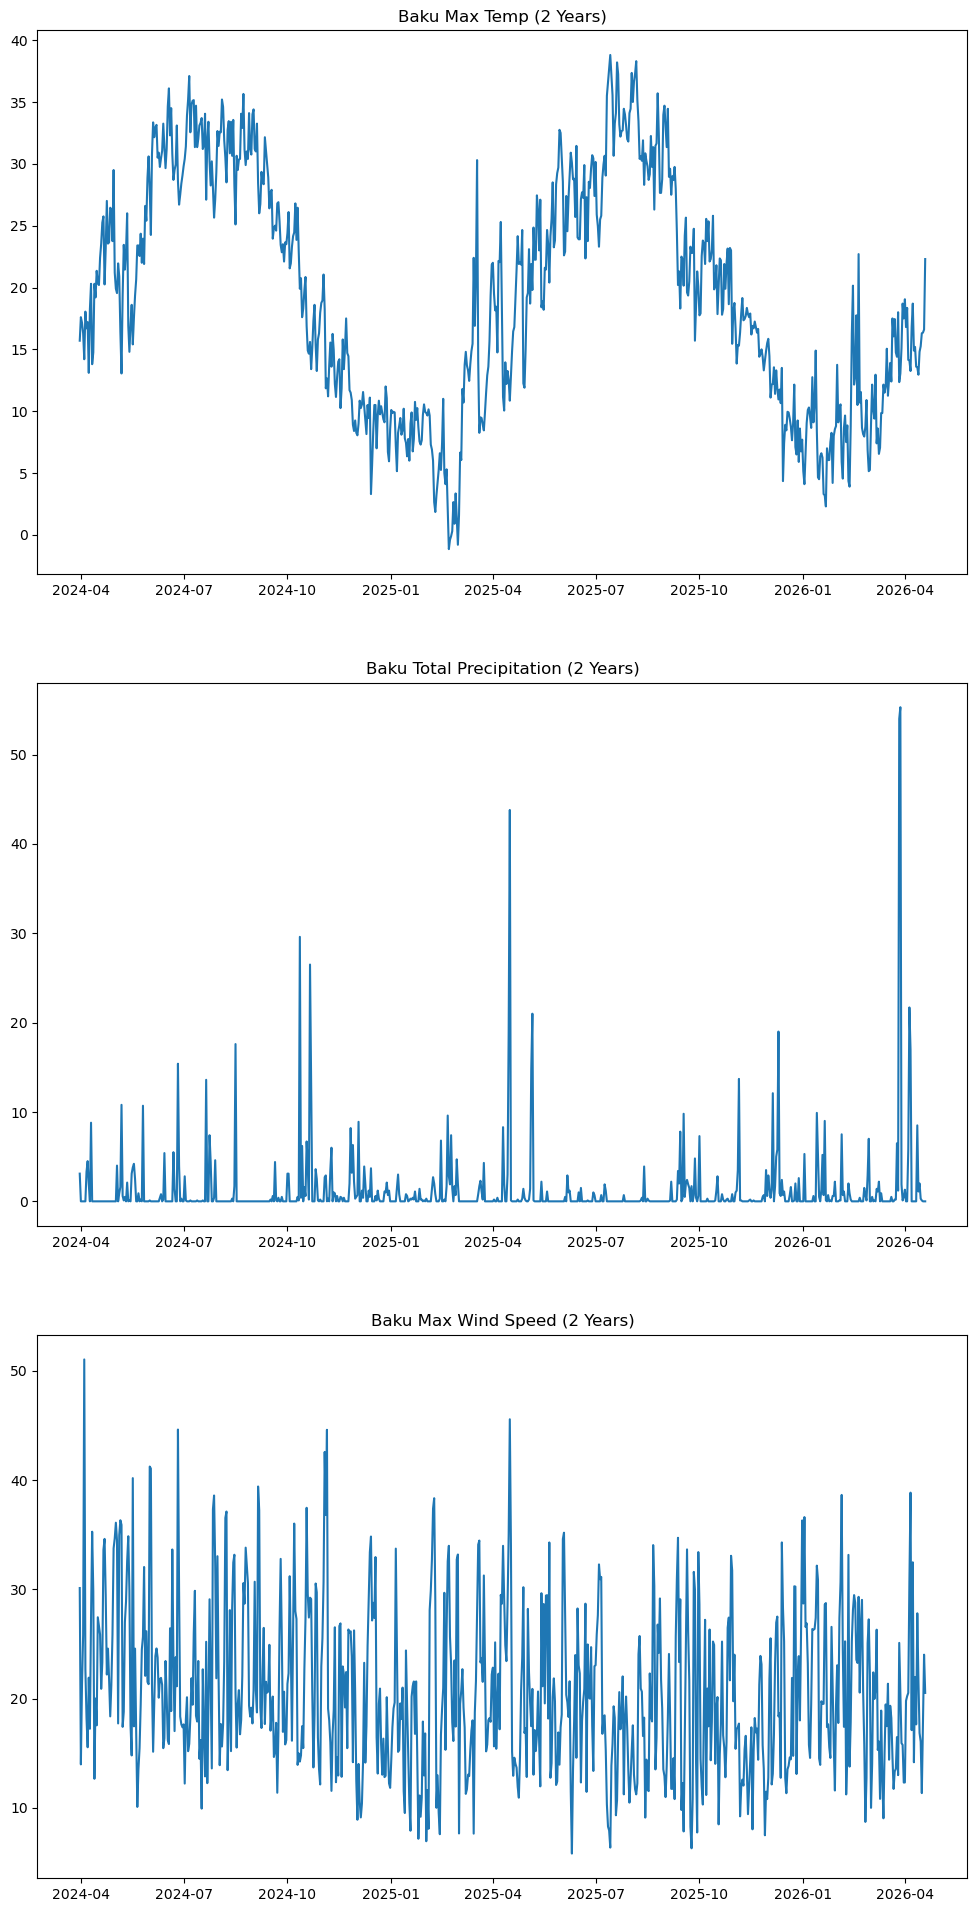

In [ ]:
# Report for Historical Data (Task 2)
print("\n--- Historical Data Summary for Hourly Data ---")
print(f"Shape: {final_hourly_df.shape}")
print(f"Columns: {final_hourly_df.columns.tolist()}")
print(f"Date Range: {final_hourly_df['date'].min()} to {final_hourly_df['date'].max()}")
print(f"Missing Values:\n{final_hourly_df.isnull().sum()[final_hourly_df.isnull().sum() > 0]}" if final_hourly_df.isnull().sum().any() else "No missing values.") # Only show columns with missing values

print("\n") # Just a line break for better readability

print("--- Historical Data Summary for Daily Data ---")
print(f"Shape: {final_daily_df.shape}")
print(f"Columns: {final_daily_df.columns.tolist()}")
print(f"Date Range: {final_daily_df['date'].min()} to {final_daily_df['date'].max()}")
print(f"Missing Values:\n{final_daily_df.isnull().sum()[final_daily_df.isnull().sum() > 0]}" if final_daily_df.isnull().sum().any() else "No missing values.") # Only show columns with missing values

print ("\n") # Just a line break for better readability

# Data for Baku
f_baku_hourly = final_hourly_df[final_hourly_df['location'] == 'Baku']
f_baku_daily = final_daily_df[final_daily_df['location'] == 'Baku']


# Visualisation
fig, ax = plt.subplots(3, 1, figsize=(12, 24))

ax[0].plot(f_baku_daily['date'], f_baku_daily['temperature_2m_max'])
ax[0].set_title("Baku Max Temp (2 Years)")

ax[1].plot(f_baku_daily['date'], f_baku_daily['precipitation_sum'])
ax[1].set_title("Baku Total Precipitation (2 Years)")

ax[2].plot(f_baku_daily['date'], f_baku_daily['wind_speed_10m_max'])
ax[2].set_title("Baku Max Wind Speed (2 Years)")




The datasets have info about daily and hourly weather measurements from March 31 2024 to today:

- Hourly data: 270,000 columns x 19 columns

- Daily data: 11250 rows x 11 columns

- Missing values: 0 missing value for both datasets, meaning datasets are highly reliable for the first steps

## About Visualization

- Max Temperature: Displays a distinct, expected seasonal bell curve, peaking sharply around 35-40°C during the summer months.

- Total Precipitation: Shows high volatility with sharp spikes (up to ~55mm) concentrated heavily in cooler/transition months, validating the presence of long, dry summer drought periods. These spikes might also mean possible floods or fatal results after heavy rains.

- Max Wind Speed: Consistently high variance throughout the year, with peak gusts frequently hitting 40-50 km/h. High wind speed may result in the increase of wildfires' spread, or the speed of ignition phase.

## Overview

- No missing values were detected in both hourly and daily datasets.
- Data appears consistent across all locations and time ranges.
- Seasonal patterns are clearly visible, especially temperature peaks in summer and precipitation spikes in colder months.
- No abnormal outliers or gaps were observed.
- Forecast data aligns with expected seasonal trends from historical data.

## Potential limitations:
- Satellite-based variables (e.g., fire occurrence) are not yet included.
- Some important wildfire indicators like vegetation dryness are approximated using vapour pressure deficit.

<h1>Task 3<h1>

In [ ]:
# Load Data
df = pd.read_csv("aze_regional_daily_weather.csv")

df = df.sort_values(["location", "date"]).reset_index(drop=True) 

df['fire_risk_proxy'] = (
    (df['temperature_2m_max'] > df['temperature_2m_max'].quantile(0.85)) &
    (df['wind_speed_10m_max'] > df['wind_speed_10m_max'].quantile(0.85)) &
    (df['precipitation_sum'] < df['precipitation_sum'].quantile(0.25))
).astype(int)

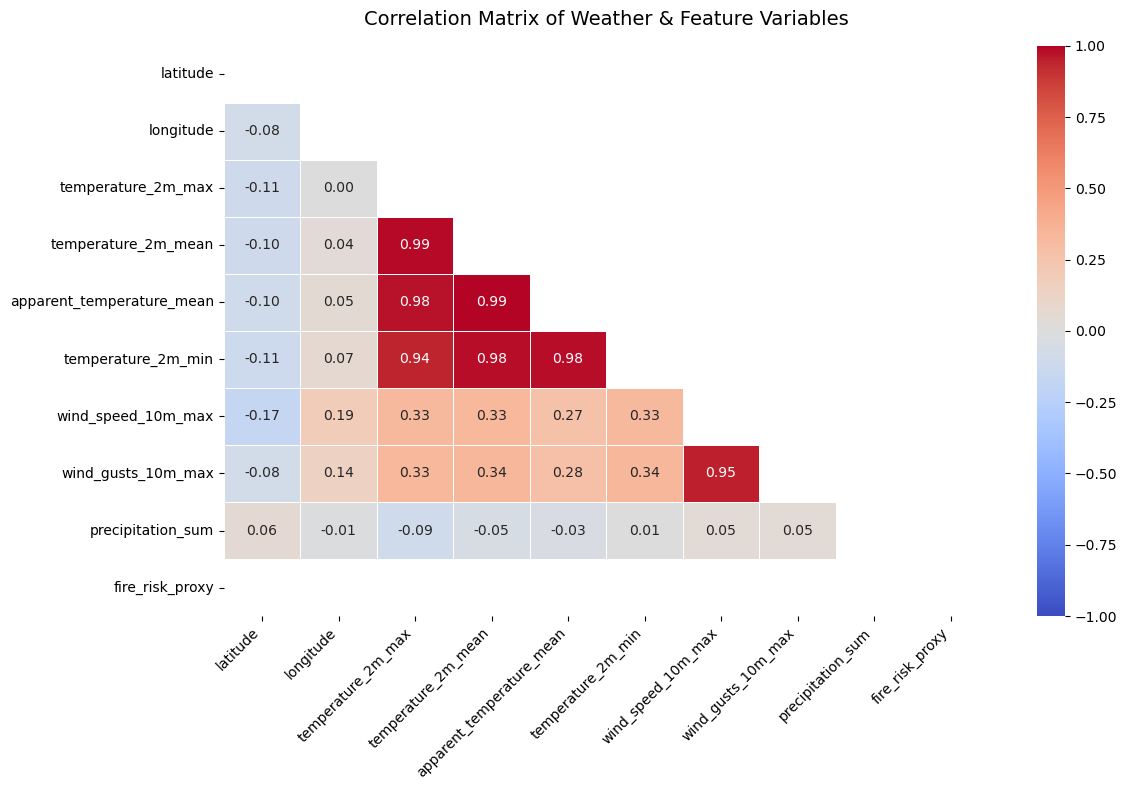


--- Correlations with Fire Risk (Proxy) ---
latitude                    NaN
longitude                   NaN
temperature_2m_max          NaN
temperature_2m_mean         NaN
apparent_temperature_mean   NaN
temperature_2m_min          NaN
wind_speed_10m_max          NaN
wind_gusts_10m_max          NaN
precipitation_sum           NaN
fire_risk_proxy             NaN
Name: fire_risk_proxy, dtype: float64


In [ ]:
#Correlation Analysis

# 1. Select only the numerical columns for correlation
numeric_cols = df.select_dtypes(include=['float64', 'float32', 'int64', 'int32'])


# 2. Calculate the correlation matrix
corr_matrix = numeric_cols.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 3. Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix, 
    mask=mask,           # Mask the upper triangle
    annot=True,          # Shows the numbers inside the squares
    fmt=".2f",           # Formats to 2 decimal places
    cmap="coolwarm",     # Red for positive correlation, Blue for negative
    vmin=-1, vmax=1,     # Sets the scale from -1 to 1
    linewidths=0.5
)

plt.title("Correlation Matrix of Weather & Feature Variables", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n--- Correlations with Fire Risk (Proxy) ---")
print(corr_matrix['fire_risk_proxy'].sort_values(ascending=False))

In [ ]:
# =========================
# 1. FEATURE ENGINEERING
# =========================

df['is_rain'] = (df['precipitation_sum'] > 1.0).astype(int)

# IMPORTANT: sort BEFORE lag/rolling
df = df.sort_values(["location", "date"]).reset_index(drop=True)

df['temp_lag1'] = df.groupby('location')['temperature_2m_max'].shift(1)

df['temp_3day_avg'] = df.groupby('location')['temperature_2m_max'] \
    .transform(lambda x: x.rolling(3, min_periods=1).mean())

df['wind_3day_avg'] = df.groupby('location')['wind_speed_10m_max'] \
    .transform(lambda x: x.rolling(3, min_periods=1).mean())

# Days since rain
df['days_since_rain'] = df.groupby(
    (df['precipitation_sum'] > 1.0).cumsum()
).cumcount()

# Drop missing values AFTER feature creation
df = df.dropna()


# =========================
# 2. FEATURES & TARGET
# =========================

X_f = df[
    [
        'temperature_2m_max',
        'temp_lag1',
        'precipitation_sum',
        'days_since_rain',
        'temp_3day_avg',
        'wind_3day_avg'
    ]
]

y_f = df['fire_risk_proxy']


# =========================
# 3. TIME-BASED SPLIT
# =========================

split_index = int(len(df) * 0.8)

X_train_f = X_f.iloc[:split_index]
X_test_f = X_f.iloc[split_index:]

y_train_f = y_f.iloc[:split_index]
y_test_f = y_f.iloc[split_index:]


# =========================
# 4. SMOTE OVERSAMPLING
# =========================

smote = SMOTE(random_state=42)

X_train_f_resampled, y_train_f_resampled = smote.fit_resample(
    X_train_f, y_train_f
)


# =========================
# 5. MODELS
# =========================

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_f_resampled, y_train_f_resampled)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_f_resampled, y_train_f_resampled)


# =========================
# 6. PREDICTIONS
# =========================

rf_pred = rf_model.predict(X_test_f)
log_pred = log_model.predict(X_test_f)


# =========================
# 7. EVALUATION
# =========================

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "F1 Score": [
        f1_score(y_test_f, log_pred),
        f1_score(y_test_f, rf_pred)
    ],
    "Accuracy": [
        accuracy_score(y_test_f, log_pred),
        accuracy_score(y_test_f, rf_pred)
    ]
})

print(results)

print("\nClass distribution:")
print(y_test_f.value_counts(normalize=True))


# =========================
# 8. CONFUSION MATRIX (RF)
# =========================

cm = confusion_matrix(y_test_f, rf_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()


# =========================
# 9. ROC CURVE (RF)
# =========================

y_prob = rf_model.predict_proba(X_test_f)[:, 1]

fpr, tpr, _ = roc_curve(y_test_f, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], '--')
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

ValueError: The target 'y' needs to have more than 1 class. Got 1 class instead

In [ ]:
print(df['fire_risk_proxy'].value_counts(normalize=True))

fire_risk_proxy
0    0.955169
1    0.044831
Name: proportion, dtype: float64


## Model Evaluation & Interpretation

This project currently uses a proxy-based wildfire risk label derived from extreme weather conditions due to the absence of labeled wildfire occurrence data. While this does not represent actual fire events, it provides a useful approximation of high-risk environmental conditions and enables an initial feasibility study.

---

### 1. Fire Risk Model (Classification)

The classification model shows moderate performance, with results influenced primarily by strong class imbalance in the dataset. Fire-risk conditions (defined by extreme temperature and wind thresholds) occur infrequently, causing the model to prioritize the majority class (non-risk days).

As a result:
- The model achieves relatively high precision for non-risk predictions
- Recall for fire-risk cases remains lower due to rarity of positive samples

This behavior is typical in highly imbalanced classification problems and does not indicate model failure, but rather dataset distribution limitations.

To improve performance in future iterations:
- Oversampling techniques such as SMOTE will be applied to balance class distribution
- The proxy-based target will be replaced with real wildfire occurrence data from NASA FIRMS
- Decision threshold tuning will be used to improve sensitivity to rare fire events

---

### 2. Weather/Soil Model (Regression)

The regression model achieves a high R² score of 0.98 when predicting mean temperature.

This performance is primarily driven by strong autocorrelation between weather variables, particularly:
- Maximum and mean temperature values
- Lagged temperature features

As a result, the model captures a largely deterministic relationship rather than a complex predictive pattern.

While this confirms consistency in the dataset, it also indicates that this regression task is relatively straightforward and should be extended toward more complex environmental targets in future work.

---

### 3. Future Improvements

To enhance realism and predictive value, the project will be extended in the following directions:
- Integration of real wildfire occurrence data from NASA FIRMS
- Prediction of soil temperature and moisture for agricultural applications
- Inclusion of additional environmental and vegetation-related variables to improve model generalization